# **Microsoft AI Innovators Internship: Titanic Exploratory Data Analysis**

Hakan Yeni, 01.08.2026-21.08.2026

ㅤㅤㅤㅤㅤ

As a part of the Microsoft AI Innovators Internship, I conducted an exploratory data analysis (EDA) on the Titanic passenger dataset using Python, Pandas, and Matplotlib. This Jupyter notebook documents the data preprocessing pipeline, data exploration and visualization, and visual analysis used to uncover key insights into passenger survival rates.

ㅤㅤㅤㅤㅤ

The core passenger features analyzed in this project include:


***Passenger Class (Pclass):*** Ticket class (1st, 2nd, 3rd Class)

***Sex (Sex):*** Gender of the passenger

***Age (Age):*** Passenger age in years

***Embarkation Port (Embarked):*** Port of departure (Cherbourg, Queenstown, Southampton)

***Survival Status (Survived):*** Target variable

# **Step 1:** **Data Acquisition and Preprocessing**
In this step, I loaded the Titanic passenger dataset into a Pandas DataFrame. I inspected the structure of the dataset verified data integrity by checking for null (missing) values and appropriate data types. I ensured that the dataset was properly cleaned and structured prior to data visualization and analysis.

In [152]:
import os
import pandas as pd
import matplotlib.pyplot as pl

os.makedirs("images", exist_ok=True) #an images directory is created to store the graphs that will be created throughout the project

pl.figure(figsize=(10, 10))
size_subplots = (10, 10)
bin_size = 10

#libraries are installed and plot sizes are set

<Figure size 1000x1000 with 0 Axes>

In [153]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv" #The URL is used to obtain the Titanic dataset rather than loading it as a file. In this way, anyone can access the dataset from this Jupyter notebook.
df_train = pd.read_csv(url)

In [154]:
df_train.head() #start of the dataset

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [155]:
df_train.tail() #end of the dataset

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [156]:
df_train.shape

(891, 12)

In [157]:
df_train.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [158]:
df_train.info() #check for nonnull values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [159]:
df_train.isnull() #Cabin, age and embarked contains null values.

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


In [160]:
df_train.isnull().sum() #This line of code makes it easier to check for null values. As there is missing values, we need to clean the data.

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [161]:
df_train['Embarked'] = df_train['Embarked'].fillna(df_train['Embarked'].mode()[0]) #data is cleaned to remove null values.

median_ages = df_train.groupby('Pclass')['Age'].transform('median')
df_train['Age'] = df_train['Age'].fillna(median_ages)
df_train['Age'] = df_train['Age'].fillna(median_ages)
df_train.drop(columns=['Cabin'], inplace=True)

df_train.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [162]:
df_train['FamilySize'] = df_train['SibSp'] + df_train['Parch'] + 1
df_train['IsAlone'] = 0
df_train.loc[df_train['FamilySize'] == 1, 'IsAlone'] = 1
df_train[['SibSp', 'Parch', 'FamilySize', 'IsAlone']].head()

,SibSp,Parch,FamilySize,IsAlone
0,1,0,2,0
1,1,0,2,0
2,0,0,1,1
3,1,0,2,0
4,0,0,1,1


In [163]:
df_train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize,IsAlone
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.066409,0.523008,0.381594,32.204208,1.904602,0.602694
std,257.353842,0.486592,0.836071,13.244532,1.102743,0.806057,49.693429,1.613459,0.489615
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400,1.000000,0.000000
50%,446.000000,0.000000,3.000000,26.000000,0.000000,0.000000,14.454200,1.000000,1.000000
75%,668.500000,1.000000,3.000000,37.000000,1.000000,0.000000,31.000000,2.000000,1.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,11.000000,1.000000


# **Step 2: Exploratory Data Analysis**
In this step, I conducted an exploratory data analysis (EDA) on the Titanic dataset that I imported in the previous step using Pandas and Matplotlib. I explored key variables: gender, passenger class, age, and embarkation status. In this way, I evaluated their individual and combined impact on passenger survival rates.


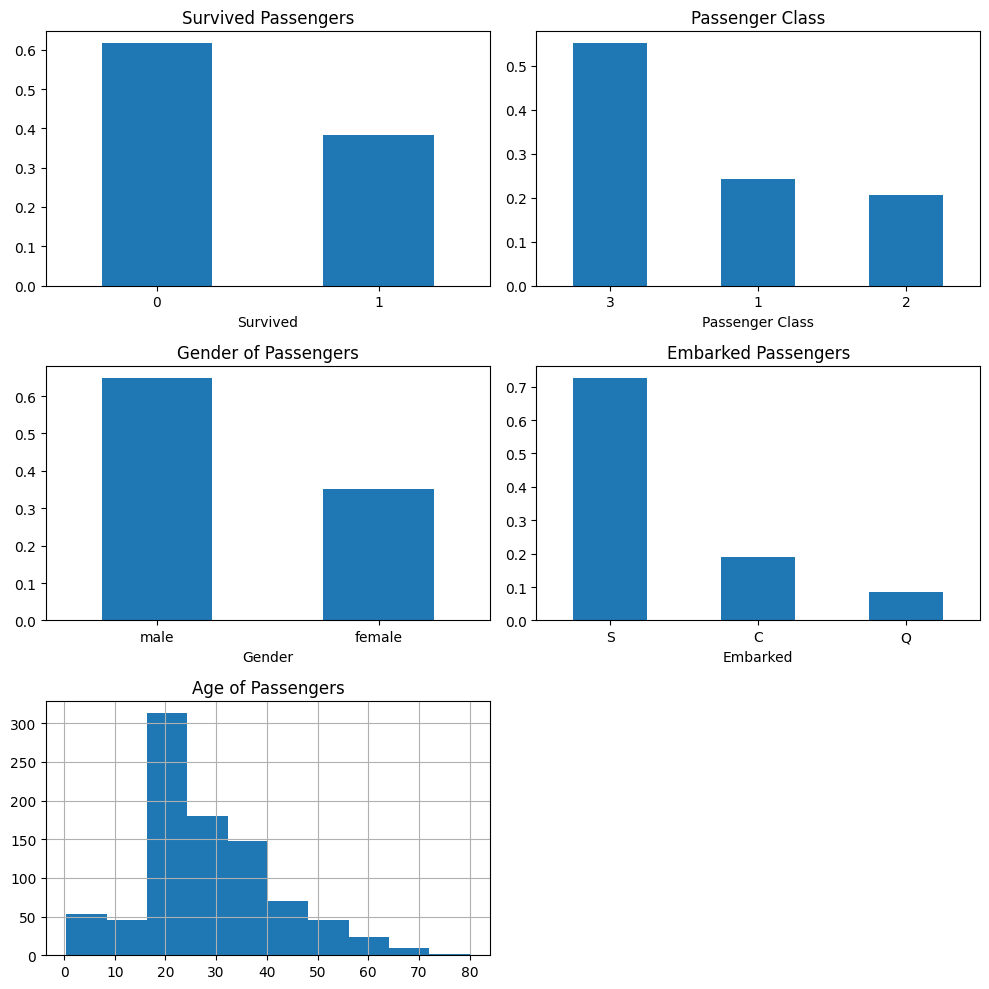

In [164]:
fig=pl.figure(figsize = size_subplots) #creates a new canvas using the same sizes from size_subplots which is written at the start
fig_dims=(3,2)
                                       #The graphs that will be analyzed later are displayed
pl.subplot2grid(fig_dims, (0, 0))
df_train['Survived'].value_counts(normalize=True).plot(kind='bar')
pl.title("Survived Passengers")
pl.xticks(rotation=0)

pl.subplot2grid(fig_dims, (0, 1))
df_train['Pclass'].value_counts(normalize=True).plot(kind='bar')
pl.title("Passenger Class")
pl.xlabel("Passenger Class")
pl.xticks(rotation=0)
pl.savefig("images/passengerclass_survivalrate1.png", dpi=300, bbox_inches="tight")

pl.subplot2grid(fig_dims, (1, 0))
df_train['Sex'].value_counts(normalize=True).plot(kind='bar')
pl.title("Gender of Passengers")
pl.xlabel("Gender")
pl.xticks(rotation=0)
pl.savefig("images/passengergender_survivalrate1.png", dpi=300, bbox_inches="tight")

pl.subplot2grid(fig_dims, (1, 1))
df_train['Embarked'].value_counts(normalize=True).plot(kind='bar')
pl.title("Embarked Passengers")
pl.xticks(rotation=0)
pl.savefig("images/passengerembarkation_survivalrate1.png", dpi=300, bbox_inches="tight")

pl.subplot2grid(fig_dims, (2,0))
df_train['Age'].hist(bins=bin_size)
pl.title("Age of Passengers")
pl.xticks(rotation=0)
pl.savefig("images/passenger_age_distribution1.png", dpi=300, bbox_inches="tight")


pl.tight_layout() #used to arrange the layout so that data and titles do not overlap.


In [165]:
pclass_xt = pd.crosstab(df_train['Pclass'], df_train['Survived']) #shows the data of survived passengers by on class
pclass_xt

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


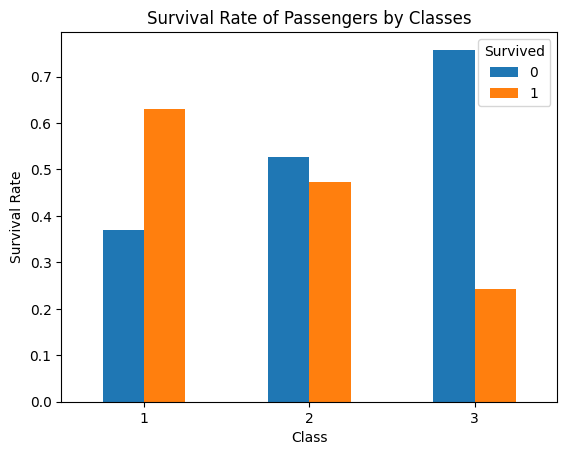

In [166]:
pclass_xt_pct = pclass_xt.div(pclass_xt.sum(1).astype(float), axis=0) #visualizes the data of survived passengers by class.
pclass_xt_pct.plot(kind = 'bar', stacked = False, title = 'Survival Rate of Passengers by Classes')
pl.xlabel ('Class')
pl.ylabel ('Survival Rate')
pl.xticks(rotation=0)
pl.savefig("images/passengerclass_survivalrate2.png", dpi=300, bbox_inches="tight")

In [167]:
sexes = sorted (df_train['Sex'].unique())
genders_mapping = dict(zip(sexes, range(0, len(sexes) + 1)))
genders_mapping

{'female': 0, 'male': 1}

In [168]:
df_train['Sex'] = df_train['Sex'].map(genders_mapping).astype(int)
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,IsAlone
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,S,2,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C,2,0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,S,1,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,S,2,0
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,S,1,1


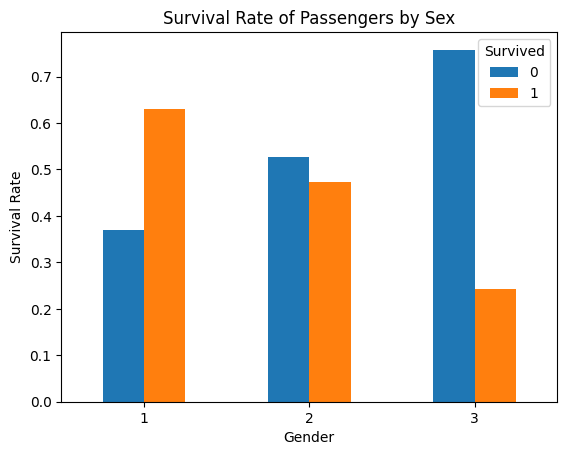

In [169]:
sexes = pd.crosstab(df_train['Sex'], df_train['Survived']) #shows the data of survived passengers by sex
pclass_xt_pct.plot(kind = 'bar', stacked = False, title = 'Survival Rate of Passengers by Sex')
pl.xlabel ('Gender')
pl.ylabel ('Survival Rate')
pl.xticks(rotation=0)
pl.savefig("images/passengergender_survivalrate2.png", dpi=300, bbox_inches="tight")

In [170]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv" #data is reloaded to eliminate the problem associated with df_train. Otherwise, the value output would be 0. Modified dataframe is now replaced with a new one.
df_train = pd.read_csv(url)

passenger_class = sorted(df_train['Pclass'].unique())

for p_class in passenger_class:  #pd.crosstab can also be used instead of the for loop.
    males_count = len(df_train[(df_train['Sex'] == "male") & (df_train['Pclass'] == p_class)])
    females_count = len(df_train[(df_train['Sex'] == "female") & (df_train['Pclass'] == p_class)])

    print("M", p_class, males_count)
    print("F", p_class, females_count)

M 1 122
F 1 94
M 2 108
F 2 76
M 3 347
F 3 144


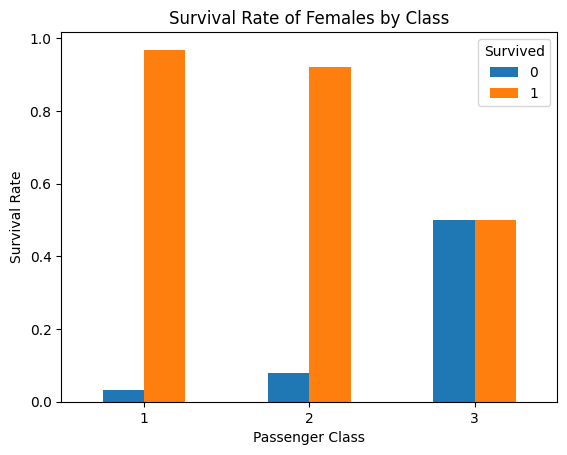

In [171]:
females_df = df_train[df_train['Sex'] == "female"]
females_xt = pd.crosstab (females_df['Pclass'], df_train['Survived'])
females_xt_pct = females_xt.div(females_xt.sum(1).astype(float), axis=0)
females_xt_pct.plot(kind = 'bar', stacked = False, title = 'Survival Rate of Females by Class')
pl.xlabel ('Passenger Class')
pl.ylabel ('Survival Rate')
pl.xticks(rotation=0)
pl.savefig("images/passengerclass_survivalratefemales.png", dpi=300, bbox_inches="tight")

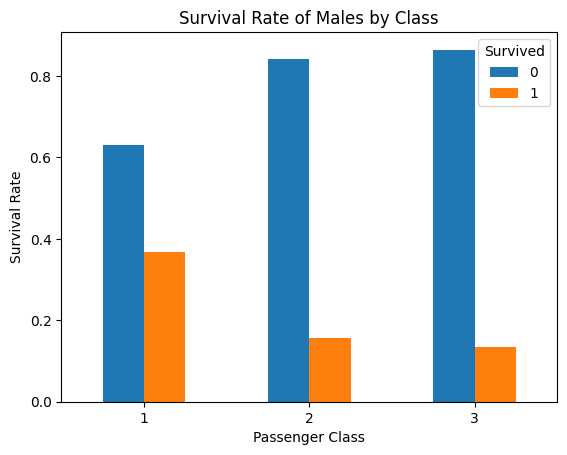

In [172]:
males_df = df_train[df_train['Sex'] == "male"]
males_xt = pd.crosstab (males_df['Pclass'], df_train['Survived'])
males_xt_pct = males_xt.div(males_xt.sum(1).astype(float), axis=0)
males_xt_pct.plot(kind = 'bar', stacked = False, title = 'Survival Rate of Males by Class')
pl.xlabel ('Passenger Class')
pl.ylabel ('Survival Rate')
pl.xticks(rotation=0)
pl.savefig("images/passengerclass_survivalratemales.png", dpi=300, bbox_inches="tight")

As can be seen from these graphs, passenger class played a crucial role in the survival rate. However, males in class 1 tended to survive more than males in class 2, while the opposite was true for female passengers.

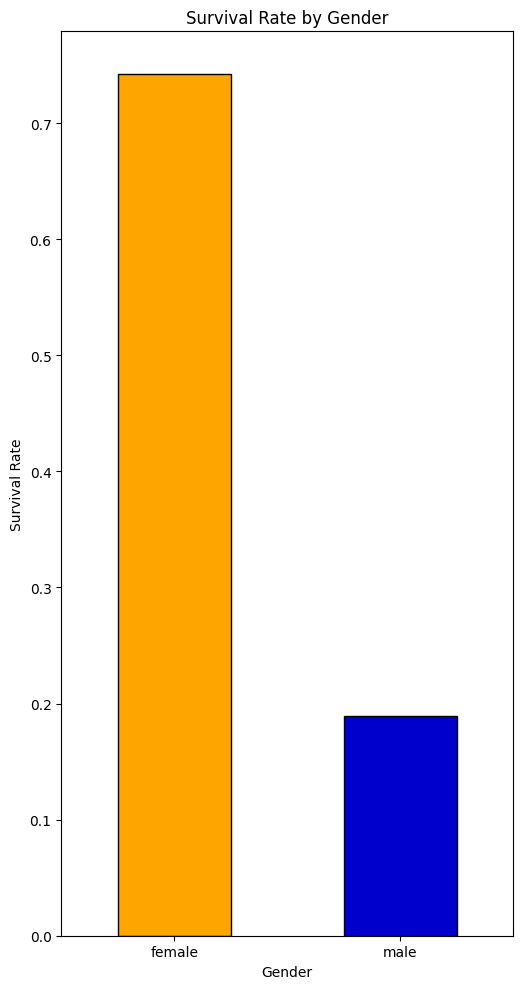

In [173]:
pl.figure(figsize=(10, 10)) #A new figure is created to display the next data.

pl.subplot(1, 2, 1)
df_train.groupby('Sex')['Survived'].mean().plot(kind='bar', edgecolor="black", color=['orange', 'mediumblue'])
pl.title("Survival Rate by Gender")
pl.xlabel("Gender")
pl.ylabel("Survival Rate")
pl.xticks(rotation=0)
pl.savefig("images/passengergender_survivalrate3.png", dpi=300, bbox_inches="tight")

pl.tight_layout()
pl.show()

This graph shows that gender was a determining factor in the survival rate. Apparently, female passengers had a survival rate that was 3 times higher than male passengers' survival rate.

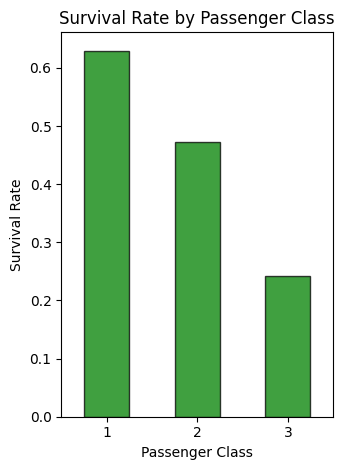

In [174]:
pl.subplot(1, 2, 2)
df_train.groupby('Pclass')['Survived'].mean().plot(kind='bar', color='green', edgecolor="black", alpha=0.75) #in this example, I also used an alpha value to change the transparency of the bars.
pl.title("Survival Rate by Passenger Class")
pl.ylabel("Survival Rate")
pl.xlabel("Passenger Class")
pl.xticks(rotation=0)
pl.savefig("images/passengerclass_survivalrate3.png", dpi=300, bbox_inches="tight")


pl.tight_layout()
pl.show()

The survival probability versus passenger class is shown in the graph above. Passengers in the first class had a noticeably higher survival rate when compared with other classes. Second class was in the middle, and third class was in last place.

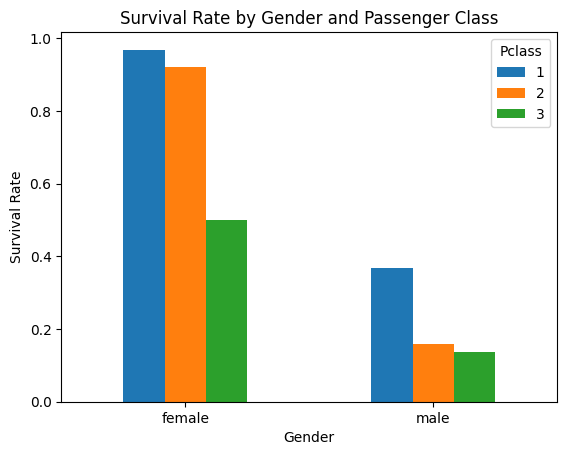

In [175]:
survival = df_train.groupby(["Sex","Pclass"])["Survived"].mean().unstack()
survival.plot(kind="bar")

pl.title("Survival Rate by Gender and Passenger Class")
pl.ylabel("Survival Rate")
pl.xlabel("Gender")
pl.xticks(rotation=0)
pl.savefig("images/passengergender_passengerclass_survivalrate.png", dpi=300, bbox_inches="tight")

pl.xticks(rotation=0)
pl.show()

The gender and passenger class data were combined into a single bar graph for greater clarity.

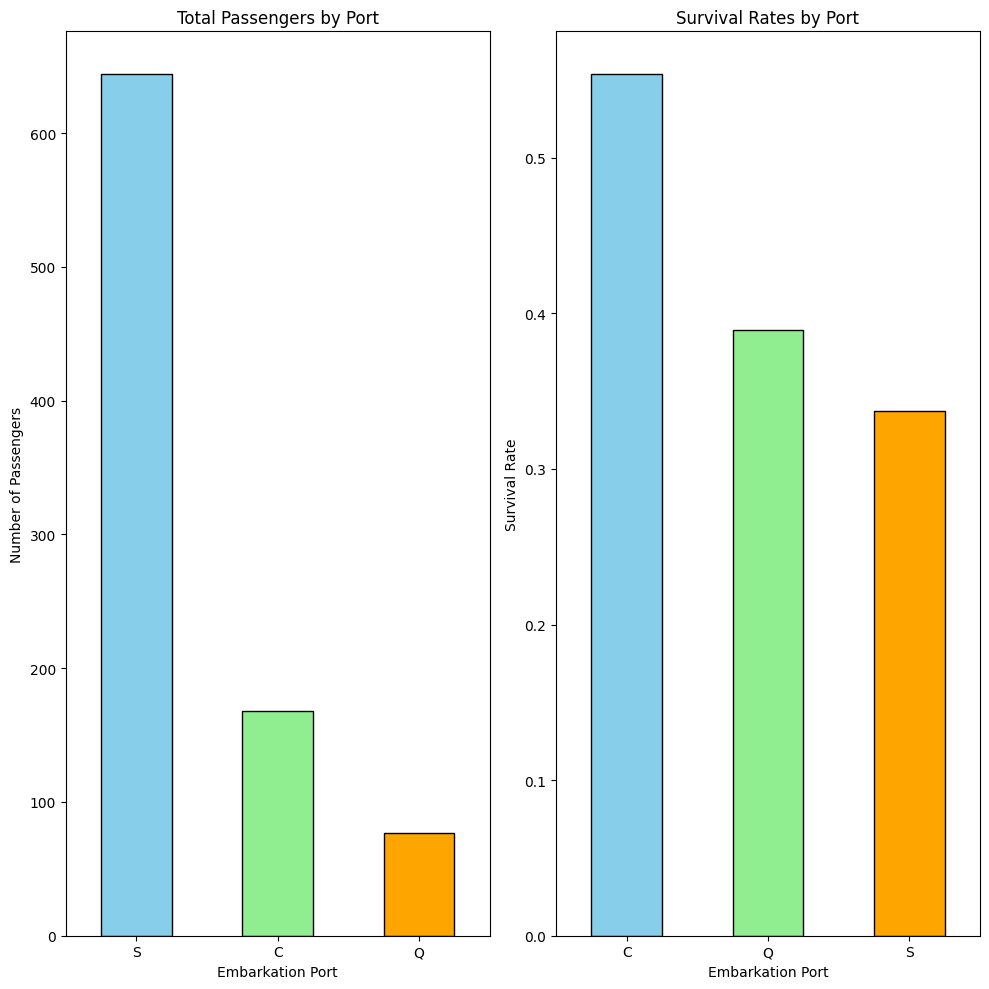

In [176]:
pl.figure(figsize=(10, 10))

pl.subplot(1, 2, 1)
df_train["Embarked"].value_counts().plot(kind="bar", edgecolor="black", color=["skyblue", "lightgreen", "orange"])
pl.title("Total Passengers by Port")
pl.ylabel("Number of Passengers")
pl.xlabel("Embarkation Port")
pl.xticks(rotation=0)
pl.savefig("images/totalpassengers_embarkation.png", dpi=300, bbox_inches="tight")

pl.subplot(1, 2, 2)
(df_train.groupby("Embarked")["Survived"].mean()).plot(kind="bar", edgecolor="black", color=["skyblue", "lightgreen", "orange"])
pl.title("Survival Rates by Port")
pl.ylabel("Survival Rate")
pl.xlabel("Embarkation Port")
pl.xticks(rotation=0)
pl.savefig("images/passengerembarkation_survivalrate3.png", dpi=300, bbox_inches="tight")

pl.tight_layout()
pl.show()

The first graph shows the total number of passengers per port, while the second shows the survival rate by embarkation port.  The number of passengers per port and the survival rate appear to correlate positively.

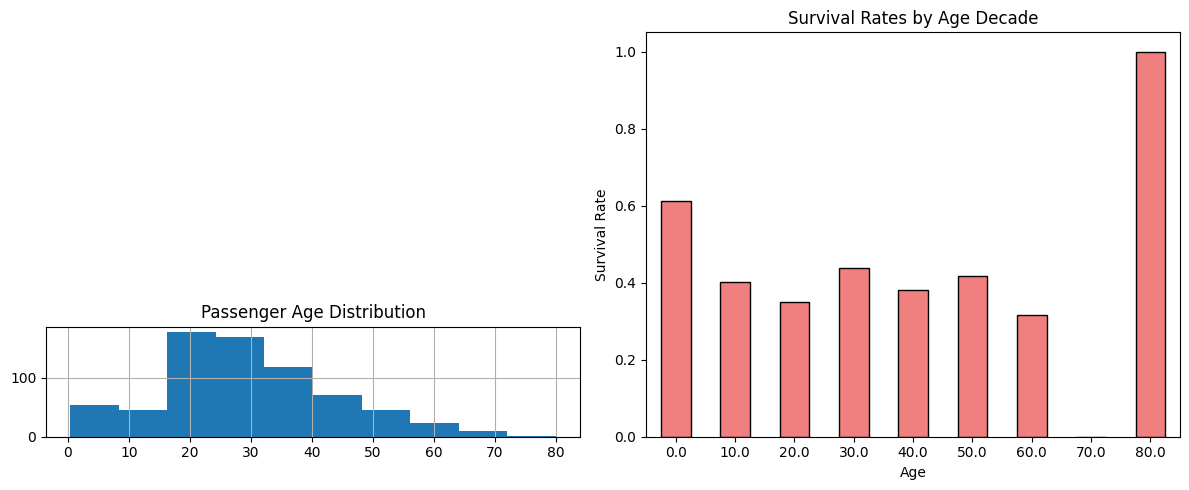

In [177]:
pl.figure(figsize=(12, 5))
pl.subplot2grid(fig_dims, (2, 0))
df_train["Age"].hist(bins=bin_size)
pl.title("Passenger Age Distribution")
pl.xticks(rotation=0)
pl.savefig("images/passenger_age_distribution2.png", dpi=300, bbox_inches="tight")

pl.subplot(1, 2, 2)
(df_train.groupby(df_train['Age'] // 10 * 10)["Survived"].mean() ).plot(kind="bar", edgecolor="black", color="lightcoral")
pl.title("Survival Rates by Age Decade")
pl.ylabel("Survival Rate")
pl.xlabel("Age")
pl.xticks(rotation=0)
pl.savefig("images/passengerage_survivalrate.png", dpi=300, bbox_inches="tight")

pl.tight_layout()
pl.show()

The ages of passengers are shown in the first graph, and their survival rate is shown in the second. It should be noted that the age values are mean values. The mean is used to remove ambiguity in the graphs. As can be seen in the graphs, there is no correlation between the age of passengers and their survival rate. For instance, there is only 1 passenger whose age was close to 80, and that passenger managed to survive. The majority were in their 20s, but age 20 has the lowest survival rate after 60 and 70. Additionally, there were no survivors with a mean age of 70.



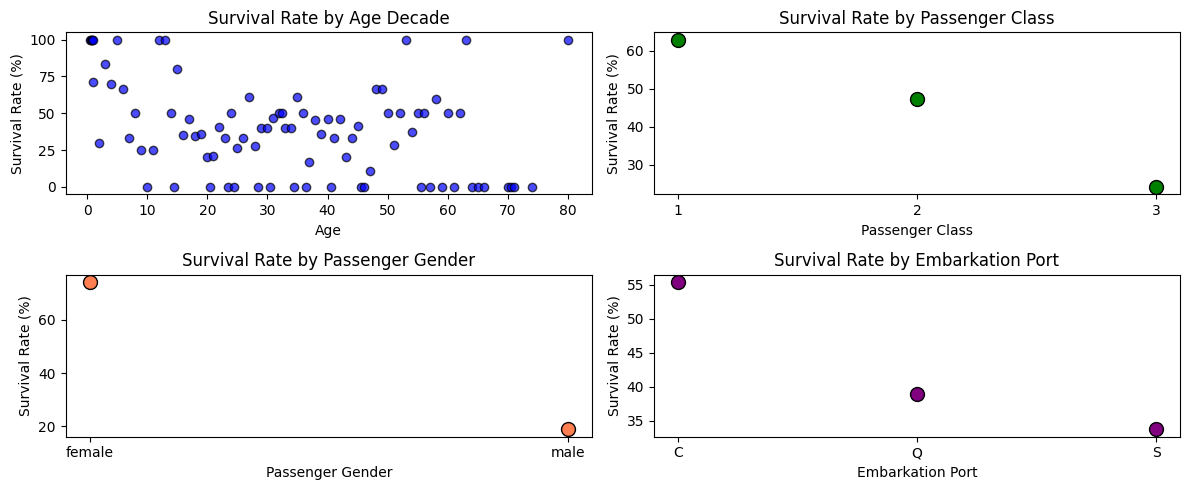

In [178]:
pl.figure(figsize=(12, 5))
pl.subplot(2, 2, 1)
age_survival = df_train.groupby('Age')['Survived'].mean() * 100
pl.scatter(age_survival.index, age_survival.values, color='blue', alpha=0.7, edgecolors='black')
pl.title("Survival Rate by Age Decade")
pl.xlabel("Age")
pl.ylabel("Survival Rate (%)")
pl.savefig("images/passengerage_survivalrate_scatter.png", dpi=300, bbox_inches="tight")

pl.subplot(2, 2, 2)
class_survival = df_train.groupby('Pclass')['Survived'].mean() * 100
pl.scatter(class_survival.index, class_survival.values, color='green', s=100, edgecolors='black')
pl.title("Survival Rate by Passenger Class")
pl.xlabel("Passenger Class")
pl.ylabel("Survival Rate (%)")
pl.xticks([1, 2, 3])
pl.savefig("images/passengerclass_survivalrate_scatter.png", dpi=300, bbox_inches="tight")

pl.subplot(2, 2, 3)
class_survival = df_train.groupby('Sex')['Survived'].mean() * 100
pl.scatter(class_survival.index, class_survival.values, color='coral', s=100, edgecolors='black')
pl.title("Survival Rate by Passenger Gender")
pl.xlabel("Passenger Gender")
pl.ylabel("Survival Rate (%)")
pl.savefig("images/passengergender_survivalrate_scatter.png", dpi=300, bbox_inches="tight")

pl.subplot(2, 2, 4)
emb_survival = df_train.groupby('Embarked')['Survived'].mean() * 100
pl.scatter(emb_survival.index, emb_survival.values, color='purple', s=100, edgecolors='black')
pl.title("Survival Rate by Embarkation Port")
pl.xlabel("Embarkation Port")
pl.ylabel("Survival Rate (%)")
pl.savefig("images/passengerembarkation_survivalrate_scatter.png", dpi=300, bbox_inches="tight")

pl.tight_layout()
pl.show()

All the values are converted into scatter plots to observe correlations. A slight correlation can be seen in "Survival Rate by Embarkation Port", "Survival Rate by Passenger Class", and "Survival Rate by Passenger Gender". However, especially in "Survival Rate by Passenger Gender", there are not a large number of different values to observe the correlation. Additionally, in "Survival Rate by Passenger Age", no correlation is found.



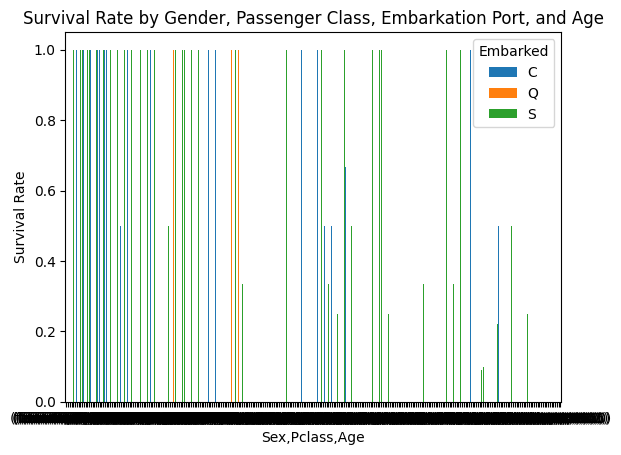

In [179]:
survival = df_train.groupby(["Sex","Pclass","Age","Embarked"])["Survived"].mean().unstack() #when we try to combine all four factors like we did with class and gender, we get a distorted graph as an output.
survival.plot(kind="bar")                                                                   #the reason for the broken graph is that there is numerous age values while there is only a few embarkation, gender, and class value.
                                                                                            #to fix this problem we need to convert the age values into decades as we did previously by using (df_train['Age'] // 10 * 10)
pl.title("Survival Rate by Gender, Passenger Class, Embarkation Port, and Age")
pl.ylabel("Survival Rate")
pl.savefig("images/broken_passengergender_passengerclass_embarkation_age_survivalrate.png", dpi=300, bbox_inches="tight")

pl.xticks(rotation=0)
pl.show()

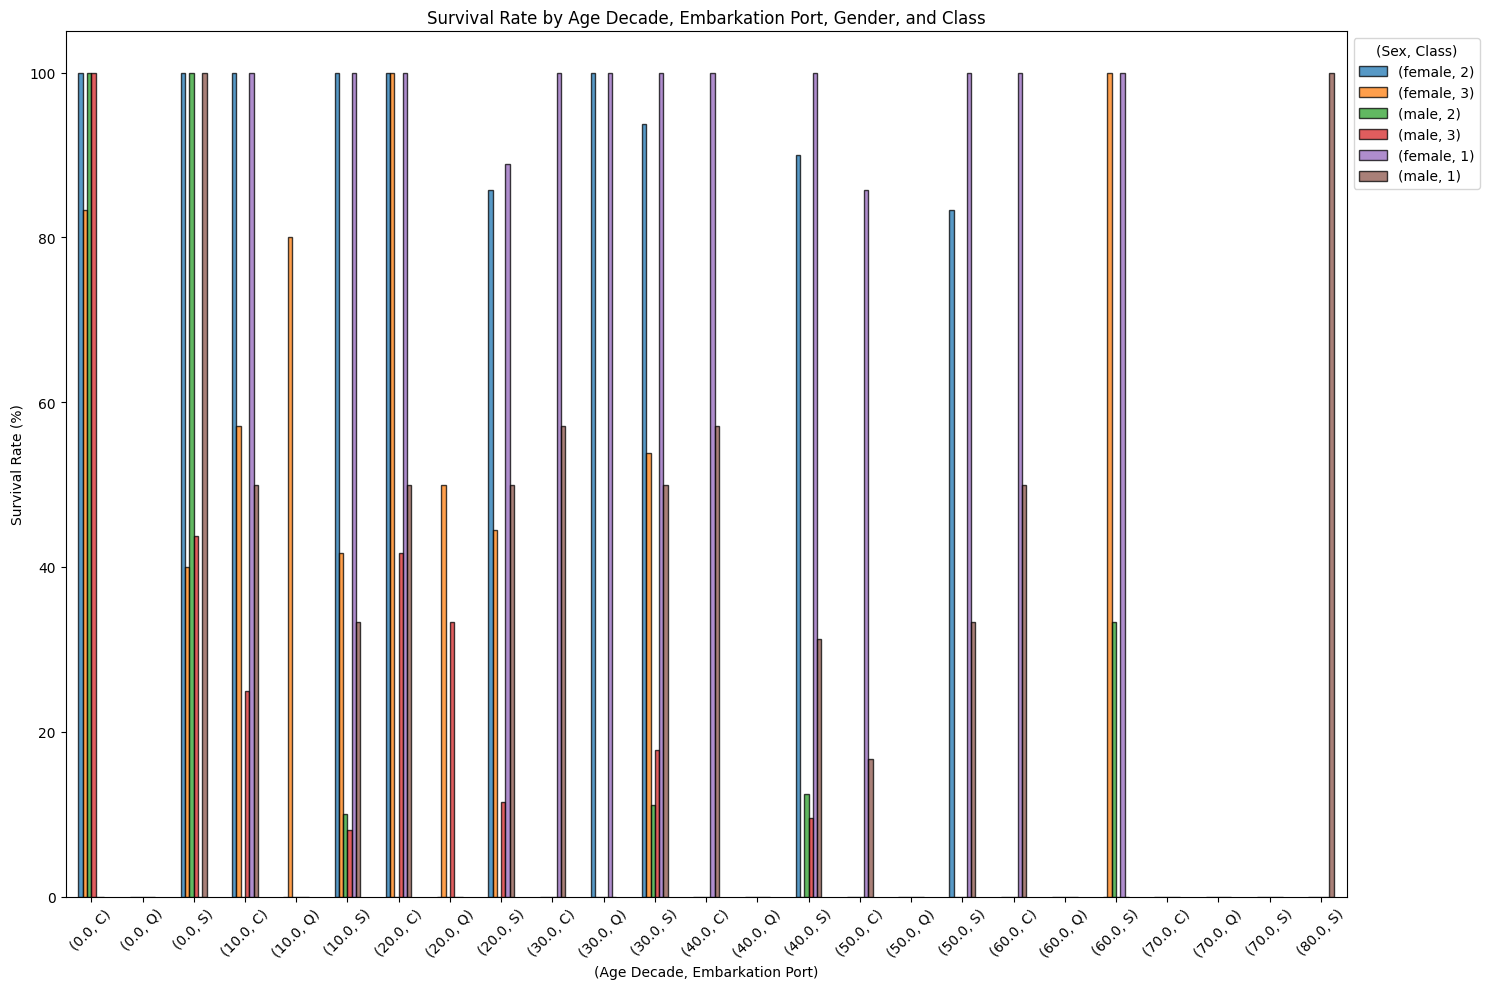

In [180]:
df_train["Age_Decade"] = df_train["Age"] // 10 * 10                                                                               #we are using decades instead of raw age values to fix the spread out bar graphs.

survival = (df_train.groupby(["Age_Decade", "Embarked", "Sex", "Pclass"])["Survived"].mean() * 100).unstack(["Sex", "Pclass"])    #we use mean values and multiply them with 100 to find the survival percentage.
                                                                                                                                  #both survival and df_train["Age_Decade"] are set as constants.
fig, ax = pl.subplots(figsize=(15, 10))
survival.plot(kind="bar", ax=ax, edgecolor="black", alpha=0.75)

pl.title("Survival Rate by Age Decade, Embarkation Port, Gender, and Class")
pl.ylabel("Survival Rate (%)")
pl.xlabel("(Age Decade, Embarkation Port)")
pl.xticks(rotation=45)                                                                                                            #text elements (x axis labels) are rotated 45 degrees to ensure clarity and increase readibility
pl.legend(title="(Sex, Class)", bbox_to_anchor=(1, 1), loc='upper left')
pl.savefig("images/true_passengergender_passengerclass_embarkation_age_survivalrate.png", dpi=300, bbox_inches="tight")

pl.tight_layout()
pl.show()

# **Conclusion**
This part discusses the results of the Titanic EDA project.

ㅤ

The Titanic sank on April 15, 1912, at 2:20 a.m. According to some resources, it carried 2,028 people onboard, with approximately 885 being crew members. In this exploration, data on 1,309 passengers is analyzed in terms of the effects of their embarkation port, gender, age, and class on their survival rate.

ㅤ

The code was written using a Jupyter notebook on Google Cloud. To write the code, Python, Pandas, and Matplotlib were used.

ㅤㅤㅤㅤㅤ

### **Discussion**

According to the data analyzed, gender had the strongest effect on survival rate, with a difference of approximately 50% between the survival rates of men and women. The second factor that had the strongest effect was passenger class, followed by embarkation port, with differences of 35% and 20% respectively between the lowest and highest survival rates. Age also played a significant role in passengers' survival rates, but it did not show a direct correlation with survival rate. This was due to the non-proportional number of passengers across different age groups.

ㅤ

The survival rate vs. influencing factor graphs are shown after the analysis of each factor. To ensure clarity, bar graphs with different colors and alpha values were used occasionally. To show the correlation between the survival rate and influencing factors, scatter plots were used. At the end of the analysis, a bar graph that shows the survival rate with respect to all of the factors was plotted.

ㅤ

All in all, the survival rate of passengers on the Titanic was not just a coincidence; it was the direct result of their gender, age, embarkation port, and class.

ㅤㅤㅤㅤㅤ

### **What I Have Learned**

Throughout this project and the Microsoft AI Innovators Internship, I learned the basics of Matplotlib while reinforcing my Python and Pandas skills. For the first time, I completed a data analysis using code and displayed my findings in the form of graphs. Beyond just coding, I developed and refined my research, analysis, and evaluation skills.


ㅤㅤㅤㅤㅤ

### **Suggestions for Future Projects**

In the future, a more extensive data analysis can be completed using the Titanic data. Other factors such as fare, family size, ticket, name, and passenger ID data can be compared. Moreover, a large language model (LLM) can be trained using the Titanic dataset to predict a random passenger's survival rate.

ㅤㅤㅤㅤㅤ

### **Reflection**

Overall, this project was a fun and educating step in my software and coding journey. With the knowledge I gained through both this project and Miscrosoft AI Innovators Internship, I am excited to continue building more projects and expanding my technical skills.